***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.3 连续谱基础成像](9_3_continuum_imaging.ipynb)
    * 下一节： [9.5 图像质量评估与测量](9_5_image_assessment_and_measurement.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.4 自校准实战：什么时候开始，什么时候停

第 8 章已经讨论过 2GC 的原理。这里的重点则是工作流视角：

- 初始模型通常不完美，但必须先足够好，才值得开始自校准；
- 第一轮往往先做 phase-only，确认模型稳定后再考虑 amplitude+phase；
- 改善幅度如果已经很小，或 residual 明显受模型缺失主导，就应当停止，而不是机械地继续迭代。


***


In [2]:
def baseline_pairs(nant):
    return [(p, q) for p in range(nant) for q in range(p + 1, nant)]


def baseline_u(ant_x_m, hour_angle_h, wavelength_m=0.214):
    pairs = baseline_pairs(len(ant_x_m))
    hour_angle_rad = np.deg2rad(15.0 * hour_angle_h)
    u = np.zeros((hour_angle_h.size, len(pairs)))
    for ti, ha in enumerate(hour_angle_rad):
        for bi, (p, q) in enumerate(pairs):
            u[ti, bi] = (ant_x_m[q] - ant_x_m[p]) * np.sin(ha) / wavelength_m
    return pairs, u


def sky_vis_1d(u, fluxes, ls):
    vis = np.zeros_like(u, dtype=complex)
    for flux, ll in zip(fluxes, ls):
        vis += flux * np.exp(-2j * np.pi * u * ll)
    return vis


def vec_to_cube(vis_vec, pairs, nant):
    nt, nb = vis_vec.shape
    cube = np.zeros((nt, nant, nant), dtype=complex)
    for bi, (p, q) in enumerate(pairs):
        cube[:, p, q] = vis_vec[:, bi]
        cube[:, q, p] = np.conj(vis_vec[:, bi])
    return cube


def cube_to_vec(cube, pairs):
    return np.stack([cube[:, p, q] for p, q in pairs], axis=1)


def apply_gains(model_cube, gains, noise_std=0.0, rng=None):
    data = gains[:, :, None] * model_cube * np.conj(gains[:, None, :])
    if noise_std > 0.0:
        if rng is None:
            rng = np.random.default_rng(0)
        data += noise_std * (
            rng.normal(size=data.shape) + 1j * rng.normal(size=data.shape)
        )
    for ant in range(data.shape[1]):
        data[:, ant, ant] = 0.0
    return data


def solve_gains(data, model, n_iter=30, ref_ant=0, phase_only=False):
    nt, nant, _ = data.shape
    gains = np.ones((nt, nant), dtype=complex)
    eps = 1e-12

    for t in range(nt):
        gt = np.ones(nant, dtype=complex)
        for _ in range(n_iter):
            new = gt.copy()
            for p in range(nant):
                mask = np.ones(nant, dtype=bool)
                mask[p] = False
                num = np.sum(data[t, p, mask] * gt[mask] * np.conj(model[t, p, mask]))
                den = np.sum(np.abs(gt[mask]) ** 2 * np.abs(model[t, p, mask]) ** 2) + eps
                new[p] = num / den
            if phase_only:
                new = new / np.maximum(np.abs(new), eps)
            ref = new[ref_ant]
            new = new / (ref / max(np.abs(ref), eps))
            gt = new
        gains[t] = gt
    return gains


def dirty_image_1d(u, vis, l_grid):
    u_flat = np.concatenate([u.ravel(), -u.ravel()])
    vis_flat = np.concatenate([vis.ravel(), np.conj(vis.ravel())])
    phase = np.exp(2j * np.pi * u_flat[:, None] * l_grid[None, :])
    return np.real(vis_flat @ phase / vis_flat.size)


def off_source_rms(image, l_grid, source_positions, exclusion=0.005):
    mask = np.ones_like(l_grid, dtype=bool)
    for pos in source_positions:
        mask &= np.abs(l_grid - pos) > exclusion
    return np.sqrt(np.mean(image[mask] ** 2))


ant_x = np.array([0.0, 40.0, 106.0, 194.0, 316.0, 462.0])
times_h = np.linspace(-3.0, 3.0, 52)
pairs, u = baseline_u(ant_x, times_h)
nant = ant_x.size

flux_true = np.array([1.0, 0.30, 0.16])
l_true = np.array([0.0, 0.012, -0.024])
vis_true = sky_vis_1d(u, flux_true, l_true)
model_true = vec_to_cube(vis_true, pairs, nant)

ant_phase = np.linspace(0.0, np.pi, nant, endpoint=False)
amp = 1.0 + 0.03 * np.sin(1.1 * times_h[:, None] + 0.5 * ant_phase[None, :])
phase = 0.60 * np.sin(2.1 * times_h[:, None] + ant_phase[None, :])
true_gains = amp * np.exp(1j * phase)
data = apply_gains(model_true, true_gains, noise_std=0.02, rng=RNG)

flux_initial = np.array([1.0])
l_initial = np.array([0.0])
model_initial = vec_to_cube(sky_vis_1d(u, flux_initial, l_initial), pairs, nant)

flux_improved = np.array([1.0, 0.28, 0.13])
l_improved = np.array([0.0, 0.012, -0.024])
model_improved = vec_to_cube(sky_vis_1d(u, flux_improved, l_improved), pairs, nant)

gains_phase = solve_gains(data, model_initial, n_iter=32, ref_ant=0, phase_only=True)
data_phase = data / (gains_phase[:, :, None] * np.conj(gains_phase[:, None, :]) + 1e-12)

gains_full = solve_gains(data_phase, model_improved, n_iter=32, ref_ant=0, phase_only=False)
data_full = data_phase / (gains_full[:, :, None] * np.conj(gains_full[:, None, :]) + 1e-12)

l_grid = np.linspace(-0.045, 0.045, 720)
image_raw = dirty_image_1d(u, cube_to_vec(data, pairs), l_grid)
image_phase = dirty_image_1d(u, cube_to_vec(data_phase, pairs), l_grid)
image_full = dirty_image_1d(u, cube_to_vec(data_full, pairs), l_grid)

rms_raw = off_source_rms(image_raw, l_grid, l_true)
rms_phase = off_source_rms(image_phase, l_grid, l_true)
rms_full = off_source_rms(image_full, l_grid, l_true)
dr_raw = image_raw.max() / rms_raw
dr_phase = image_phase.max() / rms_phase
dr_full = image_full.max() / rms_full


### 9.4.1 phase-only 先于 amplitude+phase

下面的三幅图代表典型的自校准节奏：

- 未自校准：数据仍带有明显时间相位误差；
- phase-only：核心结构显著改善，但模型不足的地方仍留下 residual；
- amplitude+phase：在模型更完整的前提下进一步压低离源噪声。


离源 RMS：raw = 0.0268, phase-only = 0.0271, amp+phase = 0.0266
动态范围：raw = 32.8, phase-only = 36.3, amp+phase = 36.5


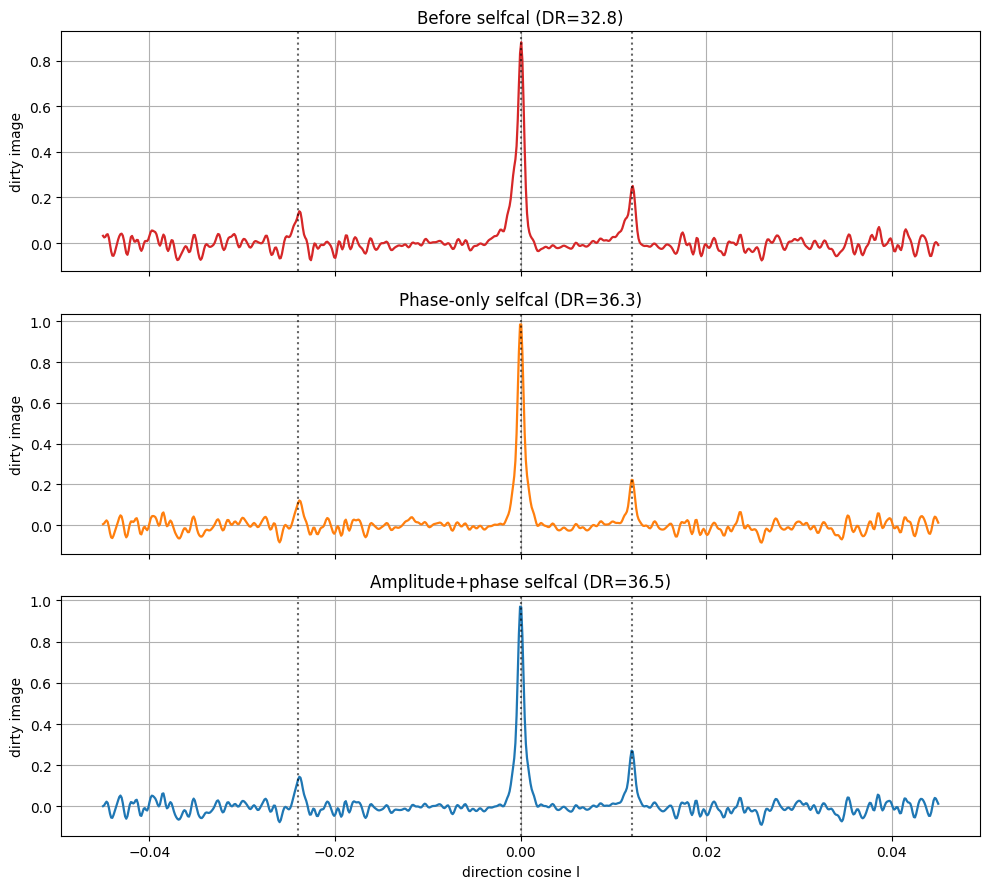

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, image, title, color in [
    (axes[0], image_raw, f"Before selfcal (DR={dr_raw:.1f})", "tab:red"),
    (axes[1], image_phase, f"Phase-only selfcal (DR={dr_phase:.1f})", "tab:orange"),
    (axes[2], image_full, f"Amplitude+phase selfcal (DR={dr_full:.1f})", "tab:blue"),
]:
    ax.plot(l_grid, image, color=color, lw=1.6)
    for pos in l_true:
        ax.axvline(pos, color="black", ls=":", alpha=0.6)
    ax.set_ylabel("dirty image")
    ax.set_title(title)

axes[2].set_xlabel("direction cosine l")
plt.tight_layout()

print(f"离源 RMS：raw = {rms_raw:.4f}, phase-only = {rms_phase:.4f}, amp+phase = {rms_full:.4f}")
print(f"动态范围：raw = {dr_raw:.1f}, phase-only = {dr_phase:.1f}, amp+phase = {dr_full:.1f}")


这个结果非常符合实践经验：第一轮 phase-only 往往带来最明显的结构改善，而 amplitude+phase 是否值得做，取决于：

- 初始模型是否已经足够稳定；
- 场内总信噪比是否支持更自由的解；
- 你的目标是进一步提高动态范围，还是已经进入收益递减区。


### 9.4.2 一个简化但实用的停止准则

自校准不应该无限循环。若后续迭代满足以下任何一种情况，就应认真考虑停止：

- 离源 RMS 改善已经很小；
- 峰值增大但弱源结构不再更可信；
- 改成更复杂解之后，绝对通量或扩展结构开始漂移；
- residual 明显是位置相关的，这更像是方向依赖问题，而不是方向无关自校准还能继续解决的问题。
